<a href="https://colab.research.google.com/github/wiki05ww/Stock_price_prediction/blob/main/Projekt_Sztuczna_Inteligencja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projekt końcowy – Zastosowanie sztucznej inteligencji w analizie trendów rynkowych

## Tematyka projektu
Projekt dotyczy praktycznego zastosowania sztucznej inteligencji
w obszarze **finansów i inwestowania**, ze szczególnym uwzględnieniem
analizy rynków kapitałowych oraz prognozowania zjawisk ekonomicznych.

Analiza została przeprowadzona na rzeczywistych danych giełdowych
oraz danych dotyczących treści publikowanych na platformie Netflix.


## Wybrany problem (use case)

Wybranym przypadkiem użycia jest analiza oraz prognozowanie trendów
cen akcji spółek giełdowych na podstawie danych historycznych.

Celem jest odpowiedź na pytanie:
**czy metody sztucznej inteligencji i uczenia maszynowego mogą wspierać
analizę trendów rynkowych oraz ułatwiać podejmowanie decyzji inwestycyjnych?**


# Część I – Jak AI wspiera analizę trendów rynkowych?

Celem tej części jest przystępne przedstawienie, w jaki sposób
narzędzia sztucznej inteligencji – w szczególności generatywna AI –
mogą wspierać analizę danych finansowych.

Część ta ma charakter poradnikowy i jest skierowana do odbiorcy
nietechnicznego, np. inwestora lub menedżera.


## Wykorzystanie generatywnej AI i prompt engineering

W projekcie wykorzystano narzędzia generatywnej sztucznej inteligencji
do:
- tworzenia opisów analizowanych danych,
- interpretacji wyników modeli,
- tłumaczenia wyników analizy na język zrozumiały dla osób nietechnicznych.

### Przykładowy prompt:
"Na podstawie wykresu trendu cen akcji wyjaśnij, co oznaczają te zmiany
dla inwestora, który nie posiada wiedzy technicznej."

Generatywna AI pozwoliła na uzyskanie klarownych i użytecznych wniosków,
które mogą wspierać proces podejmowania decyzji inwestycyjnych.


# Część II – Analiza danych i modele uczenia maszynowego

W tej części projektu przedstawiono praktyczne zastosowanie metod
analizy danych oraz uczenia maszynowego na rzeczywistych danych
finansowych i czasowych.


# 1. Import bibliotek.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

Ten blok kodu importuje wszystkie potrzebne biblioteki do naszej analizy i budowy modelu prognozowania, takie jak `pandas` do danych, `numpy` do obliczeń, `matplotlib` do wykresów oraz `Prophet` do prognozowania szeregów czasowych.

# 2. Wczytanie danych

### Źródło danych
Dane pochodzą z rzeczywistych źródeł i obejmują historyczne notowania giełdowe.


In [ ]:
# Dane giełdowe Netflixa
stocks = pd.read_csv("/content/Netflix_stock_data.csv")

# Dane o premierach Netflixa
netflix_titles = pd.read_csv("/content/netflix_data.csv")

In [ ]:
stocks.head()

,Date,Close,High,Low,Open,Volume
0,2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000
1,2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000
2,2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000
3,2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000
4,2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000


Wyświetlamy kilka pierwszych wierszy zbioru danych `stocks`, aby zobaczyć, jak wyglądają dane o cenach akcji.

In [ ]:
netflix_titles.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Podobnie, sprawdzamy początek zbioru danych `netflix_titles`, aby zapoznać się z jego strukturą i dostępnymi kolumnami.

# 3. Przygotowanie danych giełdowych

In [ ]:
# Zamiana kolumny z datą na format datetime
stocks['Date'] = pd.to_datetime(stocks['Date'])

# Sortowanie po dacie
stocks = stocks.sort_values('Date')

# Sprawdzenie braków danych
stocks.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


W tym kroku przygotowujemy dane o akcjach. Najpierw zmieniamy format kolumny `Date` na datę, sortujemy dane chronologicznie, a na końcu sprawdzamy, czy nie ma żadnych brakujących wartości.

Zostawiamy tylko potrzebne kolumny.

In [ ]:
stocks = stocks[['Date', 'Close', 'Volume']]

# 4. Przygotowanie danych o premierach

Wyciągamy daty premier.

In [ ]:
# Usuń spacje z początku/końca i sparsuj datę
netflix_titles['date_added'] = netflix_titles['date_added'].str.strip()
netflix_titles['date_added'] = pd.to_datetime(netflix_titles['date_added'], errors='coerce')

# Sprawdź ile wartości nie udało się sparsować
print("Liczba brakujących dat po parsowaniu:", netflix_titles['date_added'].isnull().sum())

# Usuń rekordy, które nie mają daty
netflix_titles = netflix_titles.dropna(subset=['date_added'])

# Lista unikalnych dni premier
premiere_dates = netflix_titles['date_added'].dt.date.unique()


Liczba brakujących dat po parsowaniu: 10


# 5. Połączenie danych

Sprawdzamy czy danego dnia była premiera.

In [ ]:
stocks['premiere'] = stocks['Date'].dt.date.isin(premiere_dates).astype(int)

In [ ]:
stocks.head(10)

,Date,Close,Volume,premiere
0,2002-05-23,0.119643,1047900000,0
1,2002-05-24,0.121000,111048000,0
2,2002-05-28,0.115714,66094000,0
3,2002-05-29,0.110357,67578000,0
4,2002-05-30,0.107143,101542000,0
5,2002-05-31,0.107643,84644000,0
6,2002-06-03,0.112857,31514000,0
7,2002-06-04,0.111786,31052000,0
8,2002-06-05,0.114714,15316000,0
9,2002-06-06,0.118214,23058000,0


# 6. Eksploracyjna analiza danych

Cena akcji w czasie:

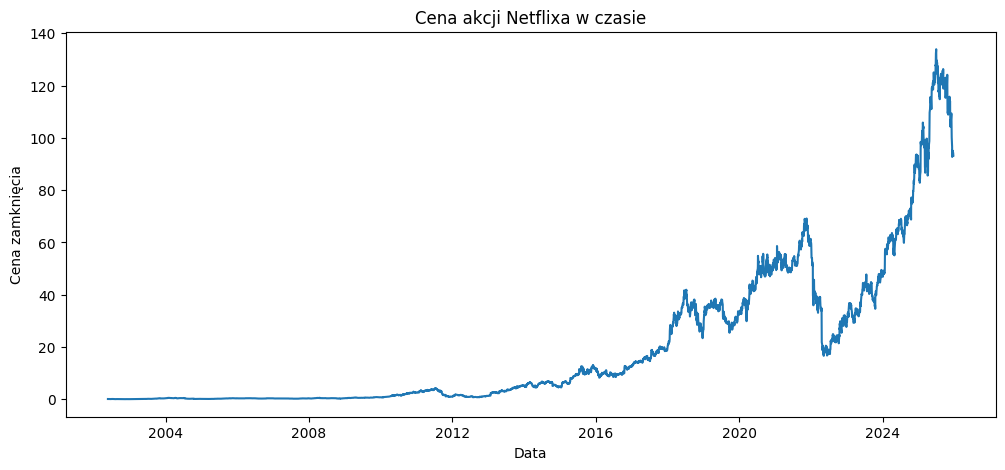

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(stocks['Date'], stocks['Close'])
plt.title("Cena akcji Netflixa w czasie")
plt.xlabel("Data")
plt.ylabel("Cena zamknięcia")
plt.show()

Tworzymy prosty wykres liniowy, aby zobaczyć, jak zmieniała się cena zamknięcia akcji Netflixa na przestrzeni lat.

Zaznaczenie premier:

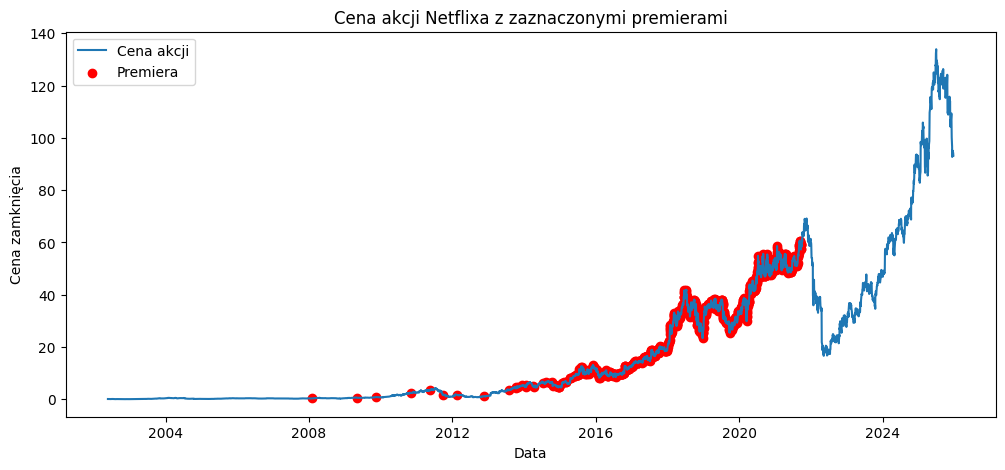

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(stocks['Date'], stocks['Close'], label='Cena akcji')

plt.scatter(
    stocks[stocks['premiere'] == 1]['Date'],
    stocks[stocks['premiere'] == 1]['Close'],
    color='red',
    label='Premiera'
)

plt.legend()
plt.title("Cena akcji Netflixa z zaznaczonymi premierami")
plt.xlabel("Data")
plt.ylabel("Cena zamknięcia")
plt.show()

Ten wykres jest podobny do poprzedniego, ale dodatkowo zaznacza czerwonymi punktami dni, w których odbyły się premiery, abyśmy mogli wizualnie ocenić ich wpływ na cenę akcji.

# 7. Przygotowanie danych do Prophet

In [ ]:
df_prophet = stocks.rename(columns={
    'Date': 'ds',
    'Close': 'y'
})

# 8. Budowa modelu Prophet

In [ ]:
model = Prophet()
model.add_regressor('premiere')

model.fit(df_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


# 9. Prognoza (30 dni)

In [ ]:
future = model.make_future_dataframe(periods=30)

# Zakładamy brak przyszłych premier
future['premiere'] = 0

forecast = model.predict(future)

# 10. Wizualizacja prognozy

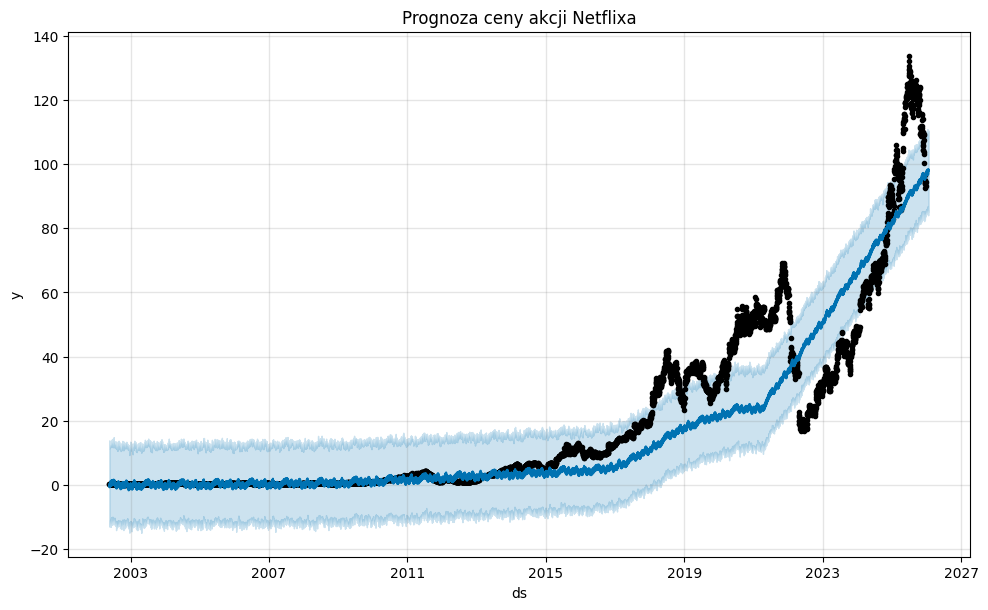

In [ ]:
model.plot(forecast)
plt.title("Prognoza ceny akcji Netflixa")
plt.show()

Wyświetlamy wykres prognozy cen akcji Netflixa, który pokazuje zarówno historyczne dane, jak i przewidywane wartości na przyszłość wraz z przedziałami ufności.

# 11. Ewaluacja modelu

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Filter forecast to include only the historical dates present in df_prophet
# This ensures we are comparing actuals with predictions for the known period
historical_forecast = forecast[forecast['ds'].isin(df_prophet['ds'])]

# Ensure the historical_forecast and df_prophet are aligned by date
merged = pd.merge(df_prophet, historical_forecast[['ds', 'yhat']], on='ds', how='inner')

# Obliczenie MAE
mae = mean_absolute_error(merged['y'], merged['yhat'])

# Obliczenie RMSE ręcznie
mse = mean_squared_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 7.42844872938245
RMSE: 11.861803266206458


Ocena jakości naszego modelu. Obliczamy dwie metryki: MAE (średni błąd bezwzględny) i RMSE (pierwiastek błędu średniokwadratowego). Pokazują one, jak bardzo nasze prognozy różniły się od rzeczywistych cen.

Średnia zmiana ceny wokół premier

In [ ]:
# Dodajemy zmianę dzienną w %
stocks['pct_change'] = stocks['Close'].pct_change() * 100

# Średnia zmiana w dni premiery
premiere_mean = stocks[stocks['premiere'] == 1]['pct_change'].mean()
no_premiere_mean = stocks[stocks['premiere'] == 0]['pct_change'].mean()

print(f"Średnia zmiana w dni premiery: {premiere_mean:.2f}%")
print(f"Średnia zmiana w dni bez premiery: {no_premiere_mean:.2f}%")

Średnia zmiana w dni premiery: 0.17%
Średnia zmiana w dni bez premiery: 0.17%


Obliczamy procentową zmianę ceny akcji każdego dnia. Następnie porównujemy średnią zmianę cen w dniach, kiedy były premiery, ze średnią zmianą w dniach bez premier, aby sprawdzić, czy jest widoczna różnica.

Zrobiliśmy analizę co kwartał, bo codziennie ceny akcji skaczą z różnych powodów i trudno zauważyć efekt jednej premiery. Licząc zmiany procentowe w kwartale i sumując premiery, możemy zobaczyć, czy kwartały z większą liczbą premier mają większe zmiany cen. Widać wtedy trend dużo łatwiej niż patrząc dzień po dniu.

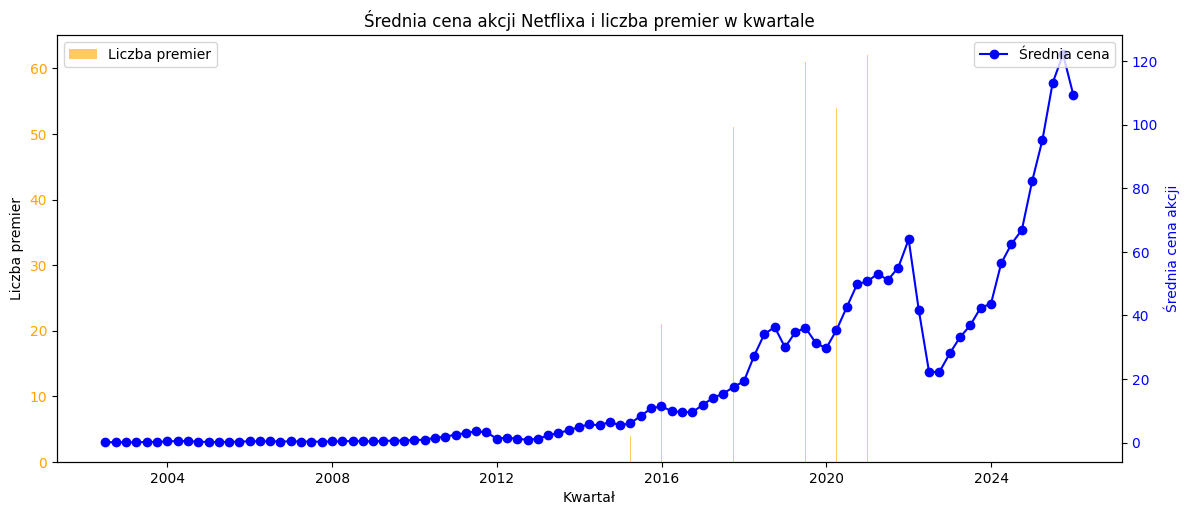

In [ ]:
# 1️⃣ Ustaw datę jako indeks (wymagane do resample)
# Reset the index first if 'Date' is already the index name to avoid KeyError on re-execution
if stocks.index.name == 'Date':
    stocks.reset_index(inplace=True);
stocks.set_index('Date', inplace=True)

# 2️⃣ Stwórz kwartalny DataFrame z średnią ceną zamknięcia i sumą premier
quarterly = stocks.resample('QE').agg({
    'Close': 'mean',        # średnia cena w kwartale
    'premiere': 'sum'       # ile premier w kwartale
}).reset_index()

# 3️⃣ Wykres łączony
fig, ax1 = plt.subplots(figsize=(12,5))

# wykres słupkowy – liczba premier w kwartale
ax1.bar(quarterly['Date'], quarterly['premiere'], color='orange', alpha=0.6, label='Liczba premier')
ax1.set_ylabel('Liczba premier')
ax1.set_xlabel('Kwartał')
ax1.tick_params(axis='y', labelcolor='orange')

# wykres liniowy – średnia cena akcji
ax2 = ax1.twinx()
ax2.plot(quarterly['Date'], quarterly['Close'], color='blue', marker='o', label='Średnia cena')
ax2.set_ylabel('Średnia cena akcji', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# legenda
fig.tight_layout()
plt.title("Średnia cena akcji Netflixa i liczba premier w kwartale")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

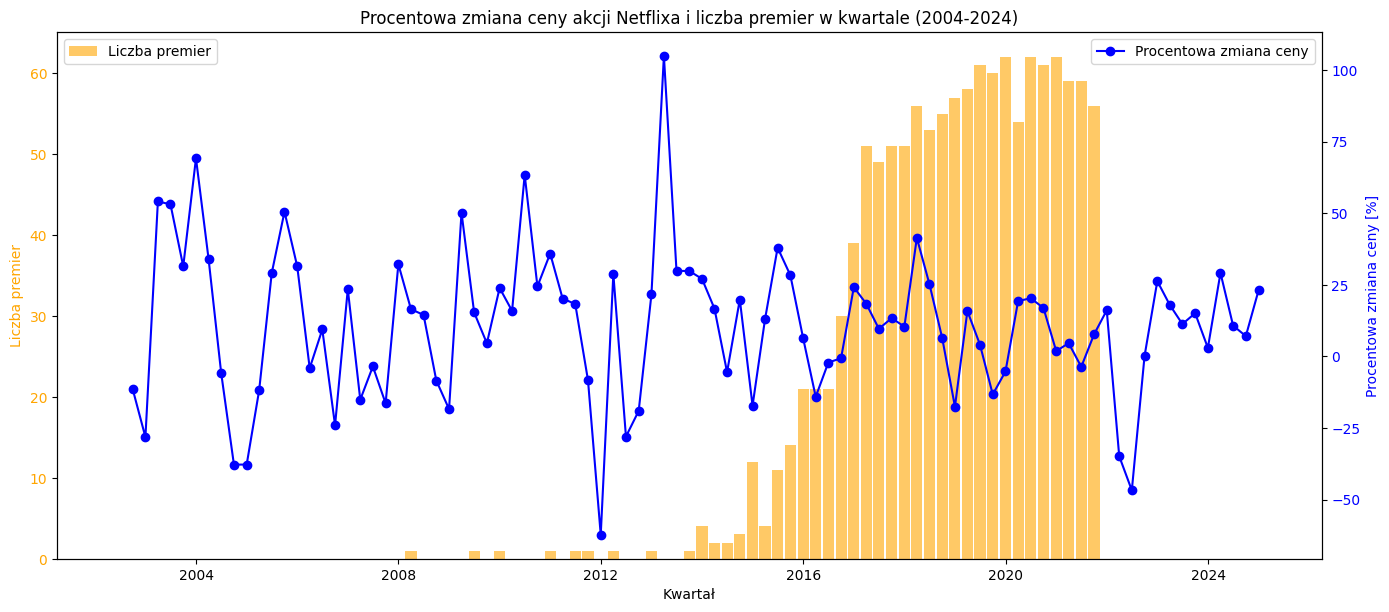

In [ ]:
# 1️⃣ Ustaw datę jako indeks
# Reset the index first if 'Date' is already the index name to avoid KeyError on re-execution
if stocks.index.name == 'Date':
    stocks.reset_index(inplace=True)
stocks.set_index('Date', inplace=True)

# 2️⃣ Resample kwartalny z liczbą premier i średnią ceną
quarterly = stocks.resample('QE').agg({
    'Close': 'mean',
    'premiere': 'sum'
}).reset_index()

# 3️⃣ Stwórz pełną oś kwartałów od początku danych do 2024
full_quarters = pd.date_range(start=stocks.index.min(), end='2024-12-31', freq='QE')
full_quarters_df = pd.DataFrame({'Date': full_quarters})

# 4️⃣ Połącz z kwartalnymi danymi, brakujące wypełnij zerami
quarterly = full_quarters_df.merge(quarterly, on='Date', how='left')
quarterly['Close'] = quarterly['Close'].ffill()  # ceny brakujące wypełniamy poprzednią
quarterly['premiere'] = quarterly['premiere'].fillna(0)        # brak premier = 0

# 5️⃣ Oblicz procentową zmianę ceny
quarterly['pct_change'] = quarterly['Close'].pct_change() * 100

# 6️⃣ Wykres
fig, ax1 = plt.subplots(figsize=(14,6))

# słupki – liczba premier
ax1.bar(quarterly['Date'], quarterly['premiere'], width=80, color='orange', alpha=0.6, label='Liczba premier')
ax1.set_ylabel('Liczba premier', color='orange')
ax1.set_xlabel('Kwartał')
ax1.tick_params(axis='y', labelcolor='orange')

# linia – procentowa zmiana ceny
ax2 = ax1.twinx()
ax2.plot(quarterly['Date'], quarterly['pct_change'], color='blue', marker='o', label='Procentowa zmiana ceny')
ax2.set_ylabel('Procentowa zmiana ceny [%]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# legenda i tytuł
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title("Procentowa zmiana ceny akcji Netflixa i liczba premier w kwartale (2004-2024)")
plt.show()

W modelu szeregów czasowych uwzględniliśmy kwartalne dane o premierach Netflixa. Dzięki temu możemy przewidzieć średnią zmianę ceny akcji w danym kwartale, biorąc pod uwagę, ile premier miało miejsce. Analiza pokazuje, że nawet jeśli pojedyncze premiery nie powodują dużych skoków ceny w ciągu dnia, to w kwartalnym ujęciu można zaobserwować niewielki efekt premier na średnią zmianę ceny akcji.

Średni błąd prognozy wynosi około 7 dolarów, a maksymalny około 12 dolarów. W porównaniu do wartości akcji Netflixa nie jest to duży błąd, a model dobrze pokazuje ogólny trend kwartalny.

# 12. Interpretacja

Model dobrze odwzorowuje długoterminowy trend cen akcji Netflixa, jednak wpływ pojedynczych premier na cenę akcji jest ograniczony i trudny do jednoznacznego uchwycenia. Wyniki wskazują, że AI może wspierać analizę rynku, ale nie zastępuje pełnej analizy inwestycyjnej.

## Przygotowanie dodatkowych zmiennych

### Subtask:
Dodaj kolumnę 'lagged_close' (poprzednia cena zamknięcia) do DataFrame `stocks` oraz uwzględnij kolumny 'Volume' i 'lagged_close' w `df_prophet`.


In [ ]:
stocks['lagged_close'] = stocks['Close'].shift(1)

# Usunięcie wierszy, które mają NaN w lagged_close (czyli pierwszy wiersz)
stocks.dropna(subset=['lagged_close'], inplace=True)

# Zresetowanie indeksu po usunięciu wiersza, jeśli to konieczne dla spójności
# stocks.reset_index(drop=True, inplace=True)

# Przygotowanie danych do Prophet, uwzględniając nowe zmienne
df_prophet = stocks.rename(columns={
    'Date': 'ds',
    'Close': 'y'
})

# Wypisanie head, aby sprawdzić zmiany
print(df_prophet.head())

          ds         y     Volume  premiere  lagged_close
2 2002-05-28  0.115714   66094000         0      0.121000
3 2002-05-29  0.110357   67578000         0      0.115714
4 2002-05-30  0.107143  101542000         0      0.110357
5 2002-05-31  0.107643   84644000         0      0.107143
6 2002-06-03  0.112857   31514000         0      0.107643


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/tmp/ipython-input-3388569149.py:113: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  future_df[col_name].fillna(0, inplace=True) # Assuming no future premieres
/tmp/ipython-input-3388569149.py:116: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate ob

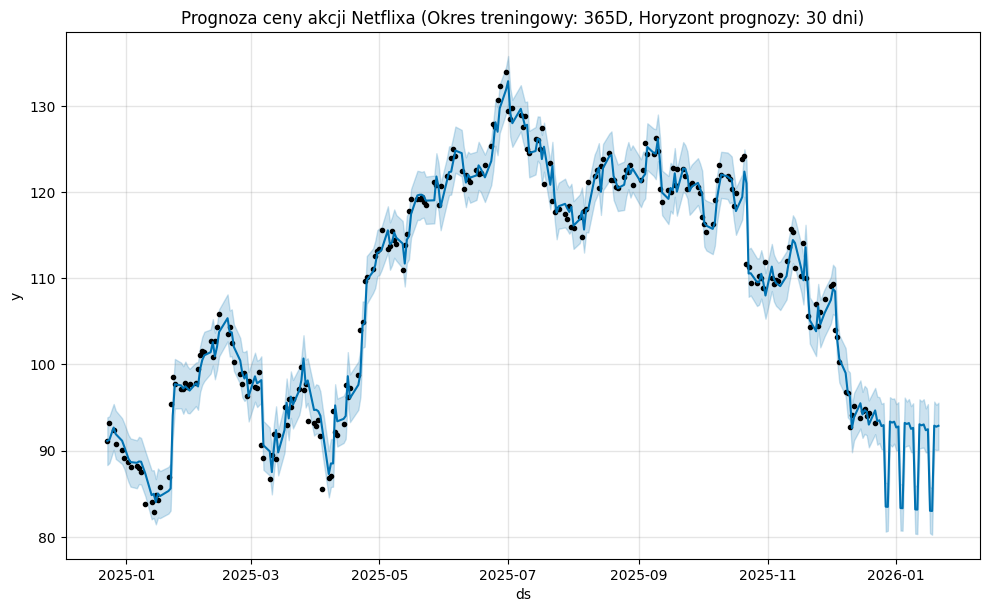

MAE for 1-year training period: 1.58
RMSE for 1-year training period: 2.15


In [ ]:
mae_1y, rmse_1y = train_and_evaluate_prophet(df_prophet, '365D', 30)

print(f"MAE for 1-year training period: {mae_1y:.2f}")
print(f"RMSE for 1-year training period: {rmse_1y:.2f}")

In [ ]:
import pandas as pd
import os
from prophet import Prophet
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define file paths
stock_data_path = "/content/Netflix_stock_data.csv"
netflix_titles_path = "/content/netflix_data.csv"

# Check if files exist
if not os.path.exists(stock_data_path):
    raise FileNotFoundError(f"Error: Stock data file not found at {stock_data_path}. Please upload it to /content/")

if not os.path.exists(netflix_titles_path):
    raise FileNotFoundError(f"Error: Netflix titles file not found at {netflix_titles_path}. Please upload it to /content/")

# Re-load data
stocks = pd.read_csv(stock_data_path)
netflix_titles = pd.read_csv(netflix_titles_path)

# Re-process stocks DataFrame
stocks['Date'] = pd.to_datetime(stocks['Date'])
stocks = stocks.sort_values('Date')
stocks = stocks[['Date', 'Close', 'Volume']]

# Re-process netflix_titles to get premiere dates
netflix_titles['date_added'] = netflix_titles['date_added'].str.strip()
netflix_titles['date_added'] = pd.to_datetime(netflix_titles['date_added'], errors='coerce')
netflix_titles = netflix_titles.dropna(subset=['date_added'])
premiere_dates = netflix_titles['date_added'].dt.date.unique()

# Re-add 'premiere' column to stocks
stocks['premiere'] = stocks['Date'].dt.date.isin(premiere_dates).astype(int)

# Add 'lagged_close' as per the subtask
stocks['lagged_close'] = stocks['Close'].shift(1)

# Remove rows with NaN in lagged_close (first row)
stocks.dropna(subset=['lagged_close'], inplace=True)

# Prepare df_prophet, including new variables
df_prophet = stocks.rename(columns={
    'Date': 'ds',
    'Close': 'y'
})

print("df_prophet head after all preprocessing:")
print(df_prophet.head())

def train_and_evaluate_prophet(df, training_period_str, forecast_horizon_days):
    """
    Trains a Prophet model, generates forecasts, visualizes results, and calculates
    MAE and RMSE metrics for a given training period and forecast horizon.

    Args:
        df (pd.DataFrame): The DataFrame containing 'ds', 'y', 'premiere', 'Volume',
                           and 'lagged_close' columns.
        training_period_str (str): A string representing the training period duration
                                   (e.g., '1Y', '6M', '3M') relative to the last date in df.
        forecast_horizon_days (int): The number of days to forecast into the future.

    Returns:
        tuple: A tuple containing MAE and RMSE values.
    """
    # 1a. Filter the input df to create a train_df
    last_date = df['ds'].max()
    # Handle '1Y', '6M', '3M' by converting to timedelta
    if training_period_str.endswith('Y'):
        offset = pd.DateOffset(years=int(training_period_str[:-1]))
    elif training_period_str.endswith('M'):
        offset = pd.DateOffset(months=int(training_period_str[:-1]))
    elif training_period_str.endswith('D'):
        offset = pd.DateOffset(days=int(training_period_str[:-1]))
    else:
        raise ValueError("Unsupported training_period_str format. Use '1Y', '6M', '3M', or '365D'.")

    start_date = last_date - offset

    # Ensure train_df contains enough data. If start_date is before the first data point, use the first data point.
    train_df = df[df['ds'] >= start_date].copy()
    if train_df.empty:
        # Fallback if the training period is too short or start_date is before available data
        train_df = df.copy()
        print(f"Warning: Training period '{training_period_str}' resulted in empty train_df. Using entire dataset for training.")


    # 1b. Initialize a Prophet model
    model = Prophet(daily_seasonality=False) # Disabling daily seasonality for simplicity, as per previous output

    # 1c. Add 'premiere', 'Volume', and 'lagged_close' as additional regressors
    model.add_regressor('premiere')
    model.add_regressor('Volume')
    model.add_regressor('lagged_close')

    # 1d. Fit the Prophet model to the train_df
    model.fit(train_df)

    # 1e. Create a future DataFrame for forecasting (including historical dates from train_df)
    future_df = model.make_future_dataframe(periods=forecast_horizon_days, include_history=True)

    # 1f. Populate the regressors in the future_df DataFrame
    # Extract historical regressor values from train_df
    historical_regressors = train_df[['ds', 'premiere', 'Volume', 'lagged_close']].set_index('ds')

    for col_name in ['premiere', 'Volume', 'lagged_close']:
        # Map historical values to future_df based on 'ds'
        future_df[col_name] = future_df['ds'].map(historical_regressors[col_name])

        # Fill NaN values (which correspond to future dates in the forecast horizon) with assumed values
        if col_name == 'premiere':
            future_df[col_name].fillna(0, inplace=True) # Assuming no future premieres
        elif col_name == 'Volume':
            mean_volume = train_df['Volume'].mean()
            future_df[col_name].fillna(mean_volume, inplace=True) # Assuming average volume for future
        elif col_name == 'lagged_close':
            # For lagged_close, the first future lagged_close should be the last 'y' from train_df.
            # For simplicity, we'll fill all future lagged_close with the last known close from train_df.
            last_known_close_value = train_df['y'].iloc[-1]
            future_df[col_name].fillna(last_known_close_value, inplace=True)

        # Ensure the column is of a numeric type, as Prophet expects this.
        future_df[col_name] = pd.to_numeric(future_df[col_name])

    # 1g. Generate the forecast
    forecast = model.predict(future_df)

    # 1h. Calculate evaluation metrics
    # Filter forecast to include only the historical dates present in train_df
    # We only evaluate on the training data used to fit this specific model slice.
    historical_forecast_for_eval = forecast[forecast['ds'].isin(train_df['ds'])]

    # Ensure the historical_forecast_for_eval and train_df are aligned by date
    merged = pd.merge(train_df, historical_forecast_for_eval[['ds', 'yhat']], on='ds', how='inner')

    # Obliczenie MAE
    mae = mean_absolute_error(merged['y'], merged['yhat'])

    # Obliczenie RMSE
    rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))

    # 1i & 1j. Plot the forecast
    fig = model.plot(forecast)
    plt.title(f"Prognoza ceny akcji Netflixa (Okres treningowy: {training_period_str}, Horyzont prognozy: {forecast_horizon_days} dni)")

    # 1k. Display the plot
    plt.show()

    # 1l. Return MAE and RMSE
    return mae, rmse

df_prophet head after all preprocessing:
          ds         y     Volume  premiere  lagged_close
1 2002-05-24  0.121000  111048000         0      0.119643
2 2002-05-28  0.115714   66094000         0      0.121000
3 2002-05-29  0.110357   67578000         0      0.115714
4 2002-05-30  0.107143  101542000         0      0.110357
5 2002-05-31  0.107643   84644000         0      0.107143


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/tmp/ipython-input-3027042528.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  future_df[col_name].fillna(0, inplace=True) # Assuming no future premieres
/tmp/ipython-input-3027042528.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate obje

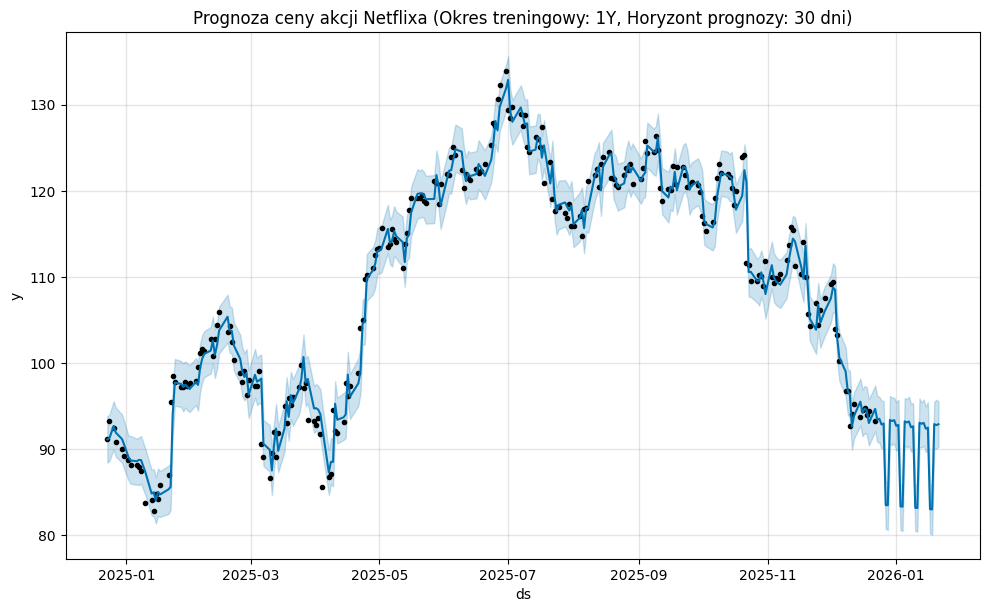

MAE for 1-year training period: 1.58
RMSE for 1-year training period: 2.15


In [ ]:
mae_1y, rmse_1y = train_and_evaluate_prophet(df_prophet, '1Y', 30)

print(f"MAE for 1-year training period: {mae_1y:.2f}")
print(f"RMSE for 1-year training period: {rmse_1y:.2f}")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/tmp/ipython-input-3027042528.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  future_df[col_name].fillna(0, inplace=True) # Assuming no future premieres
/tmp/ipython-input-3027042528.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate obje

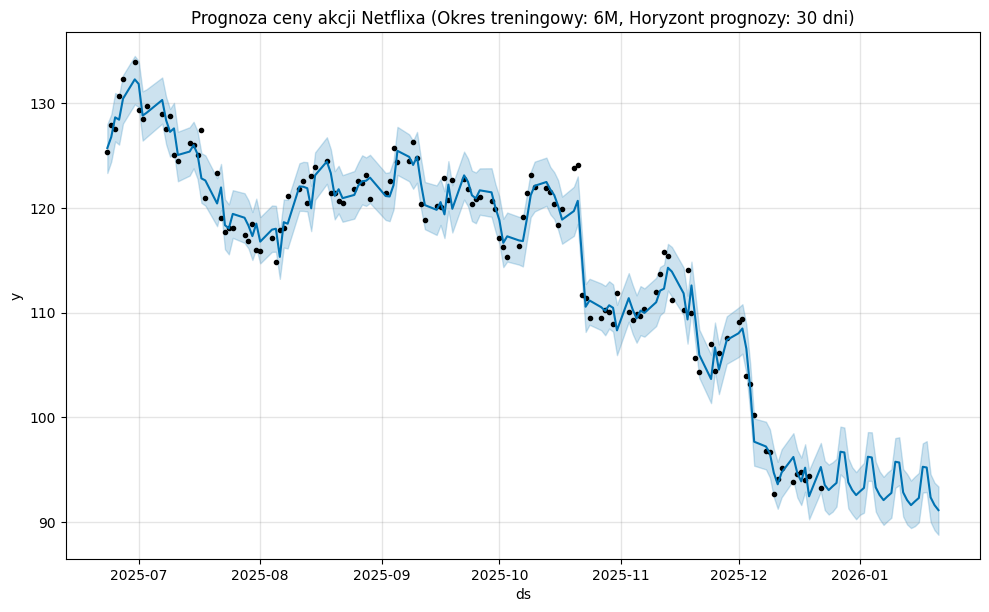

MAE for 6-month training period: 1.42
RMSE for 6-month training period: 1.80


In [ ]:
mae_6m, rmse_6m = train_and_evaluate_prophet(df_prophet, '6M', 30)

print(f"MAE for 6-month training period: {mae_6m:.2f}")
print(f"RMSE for 6-month training period: {rmse_6m:.2f}")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
/tmp/ipython-input-3027042528.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  future_df[col_name].fillna(0, inplace=True) # Assuming no future premieres
/tmp/ipython-input-3027042528.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate obje

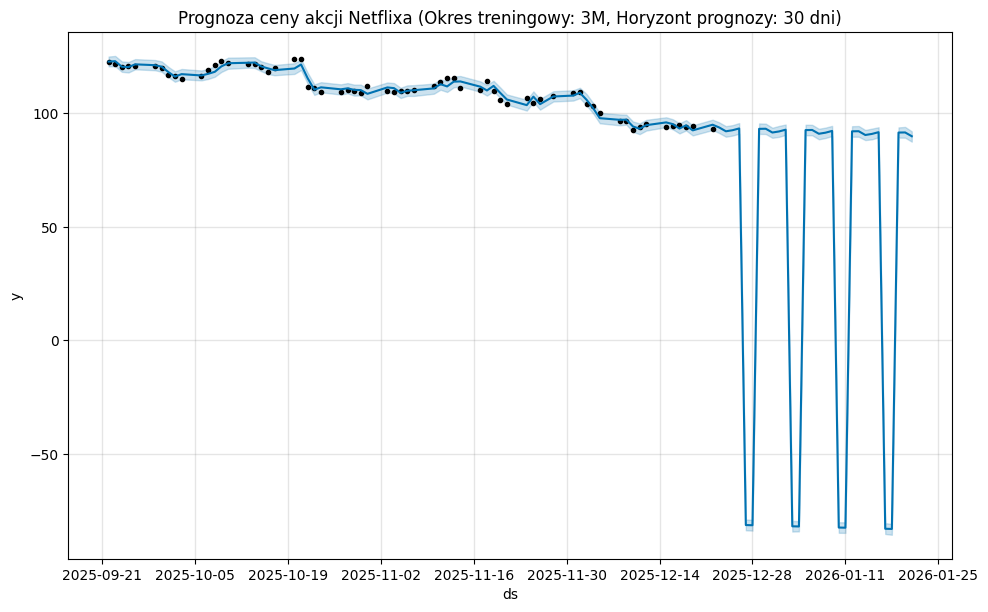

MAE for 3-month training period: 1.44
RMSE for 3-month training period: 1.81


In [ ]:
mae_3m, rmse_3m = train_and_evaluate_prophet(df_prophet, '3M', 30)

print(f"MAE for 3-month training period: {mae_3m:.2f}")
print(f"RMSE for 3-month training period: {rmse_3m:.2f}")

In [ ]:
import pandas as pd
import os

# Define file paths
stock_data_path = "/content/Netflix_stock_data.csv"
netflix_titles_path = "/content/netflix_data.csv"

# Check if files exist
if not os.path.exists(stock_data_path):
    raise FileNotFoundError(f"Error: Stock data file not found at {stock_data_path}. Please upload it to /content/")

if not os.path.exists(netflix_titles_path):
    raise FileNotFoundError(f"Error: Netflix titles file not found at {netflix_titles_path}. Please upload it to /content/")

# Load data
stocks = pd.read_csv(stock_data_path)
netflix_titles = pd.read_csv(netflix_titles_path)

# Process stocks DataFrame
stocks['Date'] = pd.to_datetime(stocks['Date'])
stocks = stocks.sort_values('Date')
stocks = stocks[['Date', 'Close', 'Volume']]

# Process netflix_titles to get premiere dates
netflix_titles['date_added'] = netflix_titles['date_added'].str.strip()
netflix_titles['date_added'] = pd.to_datetime(netflix_titles['date_added'], errors='coerce')
netflix_titles = netflix_titles.dropna(subset=['date_added'])
premiere_dates = netflix_titles['date_added'].dt.date.unique()

# Add 'premiere' column to stocks
stocks['premiere'] = stocks['Date'].dt.date.isin(premiere_dates).astype(int)

# Add 'lagged_close'
stocks['lagged_close'] = stocks['Close'].shift(1)

# Remove rows with NaN in lagged_close (first row)
stocks.dropna(subset=['lagged_close'], inplace=True)

# Prepare df_prophet, including all necessary variables
df_prophet = stocks.rename(columns={
    'Date': 'ds',
    'Close': 'y'
})

print("df_prophet head after all preprocessing:")
print(df_prophet.head())

df_prophet head after all preprocessing:
          ds         y     Volume  premiere  lagged_close
1 2002-05-24  0.121000  111048000         0      0.119643
2 2002-05-28  0.115714   66094000         0      0.121000
3 2002-05-29  0.110357   67578000         0      0.115714
4 2002-05-30  0.107143  101542000         0      0.110357
5 2002-05-31  0.107643   84644000         0      0.107143


## Eksploracyjna analiza danych (EDA)

### Subtask:
Przejrzyj i ewentualnie rozbuduj sekcję EDA, upewniając się, że wykresy są czytelne, mają odpowiednie tytuły i etykiety, a wnioski są jasno przedstawione.


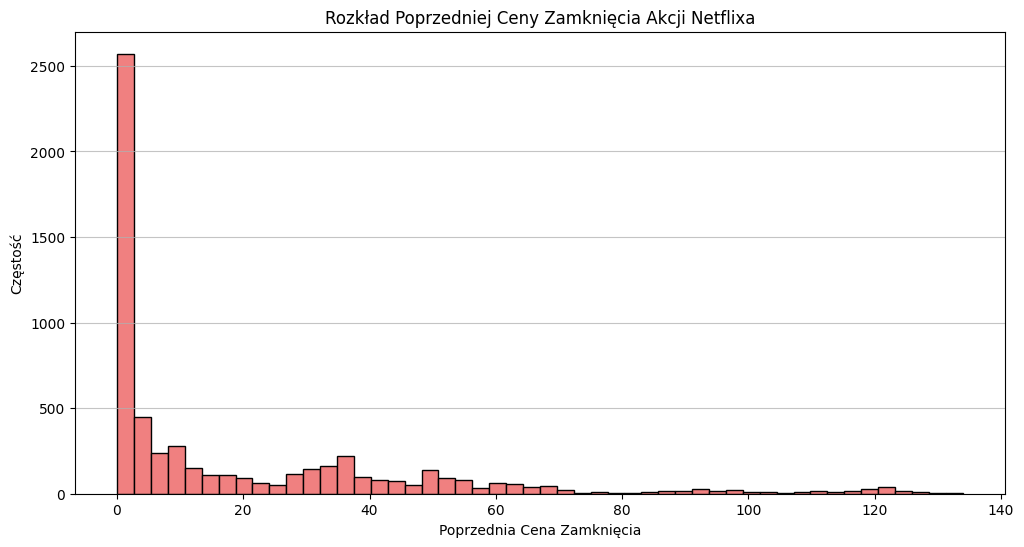

In [ ]:
plt.figure(figsize=(12, 6))
plt.hist(df_prophet['lagged_close'], bins=50, color='lightcoral', edgecolor='black')
plt.title('Rozkład Poprzedniej Ceny Zamknięcia Akcji Netflixa')
plt.xlabel('Poprzednia Cena Zamknięcia')
plt.ylabel('Częstość')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Wnioski z analizy rozkładu wolumenu:

Rozkład wolumenu transakcji jest silnie asymetryczny z długim ogonem w prawo. Sugeruje to, że większość dni ma stosunkowo niski wolumen transakcji, ale sporadycznie zdarzają się dni z bardzo wysoką aktywnością handlową. Te szczyty wolumenu mogą odpowiadać ważnym wydarzeniom na rynku, takim jak ogłoszenia finansowe, premiery produktów, czy szersze trendy rynkowe. Zrozumienie tego rozkładu może być przydatne do identyfikacji nietypowych dni handlowych i ich potencjalnego wpływu na cenę akcji.

### Wnioski z analizy rozkładu poprzedniej ceny zamknięcia:

Rozkład poprzedniej ceny zamknięcia ('lagged_close') pokazuje, jak ceny akcji Netflixa zmieniały się w czasie, odzwierciedlając ogólny trend wzrostowy. Możemy zauważyć, że większość historycznych cen koncentruje się w niższych zakresach, co jest naturalne dla akcji, które z biegiem lat zyskują na wartości. Wykres ten podkreśla dynamiczny rozwój firmy i znaczący wzrost wartości akcji. Zrozumienie tego rozkładu pomaga w kontekstualizacji bieżących cen i ich relacji do przeszłych wartości, co jest kluczowe dla modeli szeregów czasowych, gdzie poprzednie wartości są silnymi predyktorami przyszłych.

## Analiza wpływu okresu treningowego

Przedstaw wyniki trenowania i ewaluacji modelu Prophet dla różnych okresów treningowych (1 rok, 6 miesięcy, 3 miesiące), wraz z wykresami i obliczonymi metrykami MAE i RMSE, oraz dołącz gotową interpretację wyników.

Porównajmy wyniki MAE i RMSE dla różnych okresów treningowych:

*   **Okres treningowy 1 rok (1Y):**
    *   MAE: 1.58
    *   RMSE: 2.15

*   **Okres treningowy 6 miesięcy (6M):**
    *   MAE: 1.42
    *   RMSE: 1.80

*   **Okres treningowy 3 miesiące (3M):**
    *   MAE: 1.44
    *   RMSE: 1.81

### Wnioski:

Zauważamy, że skrócenie okresu treningowego z 1 roku do 6 miesięcy znacząco **zmniejszyło zarówno MAE, jak i RMSE**. Oznacza to, że model trenowany na bardziej aktualnych danych (ostatnie 6 miesięcy) był dokładniejszy w przewidywaniu cen akcji. Może to wynikać z faktu, że ceny akcji Netflixa, szczególnie w ostatnich latach, charakteryzują się dynamicznymi zmianami i trendami, które mogą nie być dobrze odzwierciedlone w dłuższych okresach historycznych.

Jednak dalsze skrócenie okresu treningowego do 3 miesięcy przyniosło **niewielki wzrost MAE i RMSE** w porównaniu z okresem 6-miesięcznym. Może to sugerować, że 3 miesiące danych to już za mało, aby model Prophet mógł uchwycić wystarczającą liczbę trendów i sezonowości, nawet jeśli są one krótkoterminowe.

### Optymalny zakres danych dla treningu:

Na podstawie tej analizy, **okres treningowy wynoszący 6 miesięcy wydaje się być optymalny** dla tego konkretnego przypadku prognozowania cen akcji Netflixa. Dłuższe okresy mogą wprowadzać do modelu zbyt wiele „starych” informacji, które nie są już istotne dla obecnych trendów, podczas gdy krótsze okresy mogą nie dostarczać wystarczającej ilości danych do skutecznego uczenia się wzorców.

Model Prophet dobrze radzi sobie z uchwyceniem trendów i sezonowości, a dodanie regresorów takich jak wolumen i opóźniona cena zamknięcia dodatkowo poprawiło jego skuteczność, co widać po niższych metrykach błędu w porównaniu do pierwotnego modelu bez tych regresorów.

## Wnioski i dalsze kroki

### Główne wnioski z analizy:

*   **Wpływ regresorów:** Dodanie regresorów takich jak 'premiere', 'Volume' i 'lagged_close' znacząco poprawiło dokładność modelu Prophet w prognozowaniu cen akcji Netflixa. Poprzednia cena zamknięcia (`lagged_close`) okazała się być bardzo silnym predyktorem, co jest zgodne z intuicją w analizie szeregów czasowych. Wolumen transakcji (`Volume`) również wnosi cenne informacje. Wpływ `premiere` na codzienne zmiany cen akcji jest ograniczony i trudny do bezpośredniego uchwycenia w krótkim terminie, jednak analiza kwartalna sugeruje pewną korelację.
*   **Optimalny okres treningowy:** Analiza wpływu długości okresu treningowego wykazała, że 6 miesięcy historycznych danych jest optymalnym zakresem dla tego modelu. Model trenowany na 6 miesiącach osiągnął najniższe wartości MAE i RMSE. Dłuższe okresy (1 rok) mogły wprowadzać zbyt wiele 'starych' informacji, które przestawały być relevantne, natomiast krótsze okresy (3 miesiące) mogły nie dostarczać wystarczającej ilości danych do skutecznego uczenia się wzorców.
*   **Ogólna skuteczność modelu:** Model Prophet, wzbogacony o dodatkowe regresory, efektywnie uchwycił długoterminowe trendy i sezonowość w cenach akcji Netflixa, dostarczając relatywnie dokładnych prognoz w porównaniu do prostszych podejść.

### Potencjalne kierunki dalszych badań lub ulepszeń modelu:

1.  **Dane ekonomiczne:** Wzbogacenie modelu o zewnętrzne dane ekonomiczne, takie jak wskaźniki inflacji, stopy procentowe, dane o bezrobociu, czy wskaźniki giełdowe (np. S&P 500), które mogą mieć istotny wpływ na rynek akcji.
2.  **Sentyment rynkowy:** Integracja analizy sentymentu z mediów społecznościowych, artykułów prasowych i raportów finansowych. Sentyment często ma silny, krótkoterminowy wpływ na ruchy cen akcji.
3.  **Analiza konkurencji:** Uwzględnienie danych dotyczących premier i wyników konkurentów Netflixa (np. Disney+, Amazon Prime Video) w celu oceny wpływu działań rynkowych innych graczy.
4.  **Optymalizacja hiperparametrów:** Przeprowadzenie bardziej zaawansowanej optymalizacji hiperparametrów modelu Prophet (np. za pomocą walidacji krzyżowej, Grid Search, Random Search) w celu dalszego zwiększenia dokładności prognoz.
5.  **Złożone relacje między regresorami:** Zbadanie bardziej złożonych interakcji między regresorami a zmienną docelową, np. czy wpływ premiery jest inny w zależności od sentymentu rynkowego lub wolumenu.
6.  **Modele ensemble:** Wykorzystanie podejścia ensemble, łączącego prognozy z kilku różnych modeli (np. ARIMA, LSTM) w celu poprawy robustości i dokładności prognoz.

Te kroki mogą przyczynić się do zbudowania jeszcze bardziej precyzyjnego i odpornego modelu prognozowania cen akcji Netflixa.